# 02 — Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
import joblib, os
os.environ["OMP_NUM_THREADS"] = "1"

apt = pd.read_csv("apt_clean.csv")
city_stats = pd.read_csv("city_stats_stage1.csv")
cities = pd.read_csv("cities.csv")
districts = pd.read_csv("districts.csv")
print("Loaded:", apt.shape, city_stats.shape, cities.shape, districts.shape)

Loaded: (4693, 30) (44, 3) (2155, 11) (25, 5)


## 5. Choosing k (Elbow + Silhouette)

C:\Users\VULCAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\VULCAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\VULCAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\VULCAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Wi

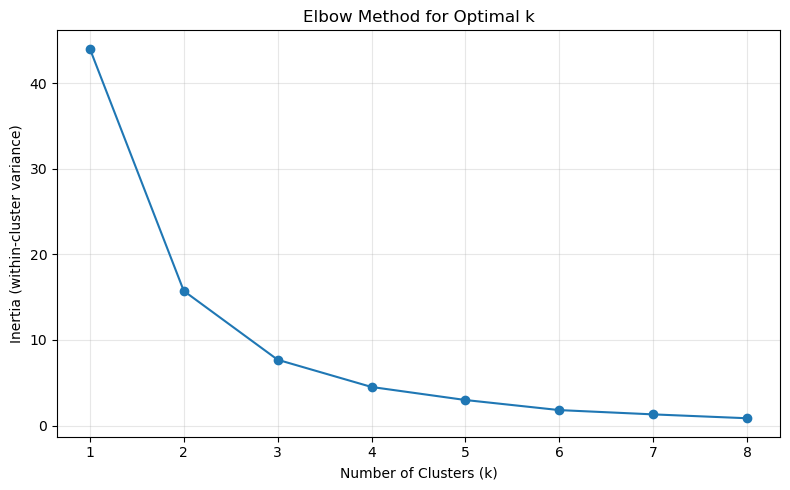

In [2]:
# Elbow method: inertia across a range of k
X = city_stats[["avg_price_per_sqft"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (within-cluster variance)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart_elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [3]:
# Quantitative validation: silhouette score and Davies-Bouldin index across candidate k values
print(f"{'k':>3} | {'Silhouette (higher=better)':>28} | {'Davies-Bouldin (lower=better)':>30}")
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    marker = "  <-- chosen k" if k == 3 else ""
    print(f"{k:>3} | {sil:>28.3f} | {db:>30.3f}{marker}")

  k |   Silhouette (higher=better) |  Davies-Bouldin (lower=better)


C:\Users\VULCAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  2 |                        0.592 |                          0.593


C:\Users\VULCAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  3 |                        0.511 |                          0.570  <-- chosen k


...

  4 |                        0.517 |                          0.537


C:\Users\VULCAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  5 |                        0.534 |                          0.479


C:\Users\VULCAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  6 |                        0.547 |                          0.457


## 6. Final Clustering (k=3)

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
city_stats["cluster"] = kmeans.fit_predict(X_scaled)

print(city_stats.groupby("cluster")["avg_price_per_sqft"].agg(["mean", "min", "max", "count"]))

C:\Users\VULCAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


                 mean           min           max  count
cluster                                                 
0        32462.238065  27597.847340  40037.420324     17
1        52198.764366  44146.841844  62377.565435      6
2        21111.072184   7598.343685  26715.471966     21


In [ ]:
ordered_clusters = np.argsort(kmeans.cluster_centers_.ravel())
label_map = {
    int(ordered_clusters[0]): "Budget & Rising",
    int(ordered_clusters[1]): "Fast Growing",
    int(ordered_clusters[2]): "Expensive & Stable"
}
city_stats["cluster_label"] = city_stats["cluster"].map(label_map)

city_stats.sort_values("avg_price_per_sqft", ascending=False)

,city_clean,avg_price_per_sqft,listing_count,cluster,cluster_label
9,Colombo 2,62377.565435,397,1,Expensive & Stable
14,Colombo 7,60353.344350,112,1,Expensive & Stable
10,Colombo 3,51001.248957,507,1,Expensive & Stable
12,Colombo 5,50494.040181,559,1,Expensive & Stable
39,Rajagiriya,44819.545431,544,1,Expensive & Stable
22,Kandana,44146.841844,3,1,Expensive & Stable
32,Nawala,40037.420324,27,0,Fast Growing
15,Colombo 8,39239.830731,143,0,Fast Growing
11,Colombo 4,36712.557980,209,0,Fast Growing
35,Nuwara Eliya City,36329.674857,8,0,Fast Growing


## 7. District-Level Coverage

In [ ]:

apt["city_for_match"] = apt["city_clean"].str.replace(" City", "", regex=False)

cities["name_clean"] = cities["name_en"].str.strip().str.title()
cities["name_for_match"] = cities["name_clean"].str.replace(" City", "", regex=False)

apt_with_district = apt.merge(
    cities[["name_for_match", "district_id"]].drop_duplicates(subset="name_for_match"),
    left_on="city_for_match", right_on="name_for_match", how="left"
)


district_name_col = [c for c in districts.columns if "name" in c.lower()][0]
district_id_col = [c for c in districts.columns if "id" in c.lower()][0]

apt_with_district = apt_with_district.merge(
    districts[[district_id_col, district_name_col]],
    left_on="district_id", right_on=district_id_col, how="left"
)

district_stats = apt_with_district.groupby(district_name_col).agg(
    avg_price_per_sqft=("price_per_sqft", "mean"),
    listing_count=("price_per_sqft", "count")
).reset_index().rename(columns={district_name_col: "district"})

district_stats = district_stats.dropna(subset=["district"])
district_stats = district_stats[district_stats["listing_count"] >= 3]

print(f"Districts with sufficient data: {len(district_stats)}")
district_stats.sort_values("avg_price_per_sqft", ascending=False)

Districts with sufficient data: 6


,district,avg_price_per_sqft,listing_count
2,Colombo,40387.240810,4503
8,Nuwara Eliya,36329.674857,8
6,Kandy,28203.828829,4
3,Galle,27723.226274,18
4,Gampaha,23844.981867,90
5,Kalutara,12503.856088,7


In [7]:
# Classify each district using the SAME trained scaler + kmeans model (no re-clustering)
district_X = district_stats[["avg_price_per_sqft"]]
district_X_scaled = scaler.transform(district_X)
district_stats["cluster"] = kmeans.predict(district_X_scaled)
district_stats["cluster_label"] = district_stats["cluster"].map(label_map)

district_stats.sort_values("avg_price_per_sqft", ascending=False)

,district,avg_price_per_sqft,listing_count,cluster,cluster_label
2,Colombo,40387.240810,4503,0,Fast Growing
8,Nuwara Eliya,36329.674857,8,0,Fast Growing
6,Kandy,28203.828829,4,0,Fast Growing
3,Galle,27723.226274,18,0,Fast Growing
4,Gampaha,23844.981867,90,2,Budget & Rising
5,Kalutara,12503.856088,7,2,Budget & Rising


## 8. Trend Proxy

In [8]:
apt["posted_date"] = pd.to_datetime(apt["posted_date"], errors="coerce", utc=True)
apt["year"] = apt["posted_date"].dt.year

print(apt["year"].value_counts().sort_index())

year
2022    1736
2023    2957
Name: count, dtype: int64


In [9]:
def yoy_trend(city_name, min_per_year=3):
    rows = apt[apt["city_clean"] == city_name]
    yearly = rows.groupby("year")["price_per_sqft"].agg(["mean", "count"])
    if 2022 not in yearly.index or 2023 not in yearly.index:
        return None
    if yearly.loc[2022, "count"] < min_per_year or yearly.loc[2023, "count"] < min_per_year:
        return None
    pct_change = (yearly.loc[2023, "mean"] - yearly.loc[2022, "mean"]) / yearly.loc[2022, "mean"] * 100
    return round(pct_change, 1)

city_stats["yoy_trend_pct"] = city_stats["city_clean"].apply(yoy_trend)

n_with_trend = city_stats["yoy_trend_pct"].notna().sum()
print(f"Cities with a usable trend value: {n_with_trend} / {len(city_stats)}")
city_stats[["city_clean", "avg_price_per_sqft", "cluster_label", "yoy_trend_pct"]]

Cities with a usable trend value: 28 / 44


,city_clean,avg_price_per_sqft,cluster_label,yoy_trend_pct
0,Angoda,16132.442854,Budget & Rising,NaN
1,Athurugiriya,24682.467363,Budget & Rising,-2.8
2,Battaramulla,32554.611845,Fast Growing,-4.8
3,Boralesgamuwa,28013.129364,Fast Growing,-8.4
4,Colombo 10,33377.672091,Fast Growing,7.0
5,Colombo 12,21482.542795,Budget & Rising,NaN
6,Colombo 13,23354.539109,Budget & Rising,NaN
7,Colombo 14,13730.731533,Budget & Rising,NaN
8,Colombo 15,27607.989924,Fast Growing,4.1
9,Colombo 2,62377.565435,Expensive & Stable,5.7


## 9. Similar Cities

In [ ]:
from ml_utils import get_similar_cities

test_city = city_stats["city_clean"].iloc[0]
print(f"Similar to {test_city}: {get_similar_cities(city_stats, test_city)}")

Similar to Angoda: ['Mount Lavinia', 'Athurugiriya', 'Kottawa']


In [11]:
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
city_stats.to_csv("city_stats_stage2.csv", index=False)
district_stats.to_csv("district_stats_stage2.csv", index=False)
print("Saved kmeans_model.pkl, scaler.pkl, city_stats_stage2.csv, district_stats_stage2.csv")

Saved kmeans_model.pkl, scaler.pkl, city_stats_stage2.csv, district_stats_stage2.csv
